# Visualizing the RF Output of QICK

**Author:** Victor Marcenac  
**Date:** November 2025  
**Hardware:** RFSoC 4x2 with QICK-DAWG

## Overview

This notebook provides an interactive visualization of how the RFSoC 4x2 with QICK-DAWG generates RF signals. It breaks down the signal generation process into fundamental components to help users develop intuition about the system's operation.

### Key Components (DAC)
1. **NCO (Numerically Controlled Oscillator)** - Generates carrier frequencies
2. **DDS (Direct Digital Synthesizer)** - Creates waveform envelopes
3. **Mixer** - Combines NCO and DDS signals

### Learning Objectives
- Understand NCO operation and frequency generation
- Visualize how waveforms are synthesized from DDS & the NCO
- See the complete signal chain from digital to RF
- Understand the I & Q channels effect on phase and amplitude of the resulting signal

## 1. Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# RFProto modules for simulating the nco
from rfproto import measurements, nco, plot

# Set plot style for better visibility
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### 1.2 System Constants

Define the key parameters for the QICK-DAWG system.

In [ ]:
# DAC Clock Configuration
# NCO clock: 4915.2 MHz (409.6 MHz × 12 upsampling factor)
# DDS sample rate: 4915.2 MHz (307.6 MHz tproc × 16 samples/tproc)
FREQ_DAC = 4915.2e6  # 4915.2 MHz (409.6 MHz × 12 upsampling factor)

# NCO Configuration
PHASE_WORD_LEN = 32  # bits - determines frequency resolution
PHASE_RESOLUTION = 2 * np.pi / (2 ** PHASE_WORD_LEN)  # radians

# DDS & FPGA (tproc) Configuration
FREQ_TPROC = 307.6e6        # tproc clock: ~307.6 MHz
WVFM_CHANNEL_BIT_DEPTH = 16  # bits / channel / Sample
SAMPLES_PER_TPROC = 16      # samples / tproc cycle
FREQ_WVFM = FREQ_TPROC * SAMPLES_PER_TPROC # Same as DAC (4915.2 MHz)
# waveform and dac frequency are expected to match


# Memory
WAVEFORM_MEMORY = 2**16     # Samples (65536 samples {I&Q}, 13.33 us)

print(f"System Configuration:")
print(f"  DAC Clock: {FREQ_DAC/1e6:.1f} MHz")
print(f"  tproc (FPGA) Clock: {FREQ_TPROC/1e6:.1f} MHz")
print(f"  Phase Resolution: {PHASE_RESOLUTION:.2e} rad")
print(f"  Frequency Resolution: {FREQ_DAC * PHASE_RESOLUTION / (2*np.pi):.3f} Hz")

System Configuration:
  DAC Clock: 4915.2 MHz
  tproc (FPGA) Clock: 307.6 MHz
  Phase Resolution: 1.46e-09 rad
  Frequency Resolution: 1.144 Hz


## 2. Numerically Controlled Oscillator (NCO)

The NCO is the heart of the frequency generation system. It uses a phase accumulator architecture:

```
Frequency Control Word → [+] → [Phase Register] → Phase-to-Amplitude → Output
                          ↑           ↓
                          └────[DFF]──┘
                       DAC Clock ↑
```

### 2.1 NCO Theory

- **Phase Accumulator**: Adds frequency control word each clock cycle
- **Frequency Control Word**: Determines output frequency
- **Phase Word Length**: 32 bits, provide 2³² possible phases
- **Output Frequency**: f_out = (FCW / 2³²) × f_DAC
- **PAC**: Phase-to-Amplitude typically uses a LUT (Look-up table) + interpolation

In [ ]:
def calculate_fcw(freq_desired, freq_dac=FREQ_DAC, phase_word_len=PHASE_WORD_LEN):
    """Calculate the Frequency Control Word for a desired frequency.
    
    Args:
        freq_desired: Target frequency in Hz
        freq_dac: DAC clock frequency in Hz
        phase_word_len: Length of phase word in bits
    
    Returns:
        int: Frequency Control Word
    """
    fcw = int((freq_desired / freq_dac) * (2 ** phase_word_len))
    actual_freq = (fcw / (2 ** phase_word_len)) * freq_dac
    error = actual_freq - freq_desired
    
    print(f"Desired Frequency: {freq_desired/1e6:.6f} MHz")
    print(f"FCW: {fcw} (0x{fcw:08X}, or {fcw/2**33:.3f} rad)")
    print(f"Actual Frequency: {actual_freq/1e6:.9f} MHz")
    print(f"Frequency Error: {error:.3f} Hz")
    
    return fcw

def run_nco(freq_out, phase_offset_deg=0, num_samples=64, plot=False, use_rfproto=False):
    """Generate NCO output (normalized) for given frequency.
    
    Args:
        freq_out: Output frequency in Hz
        phase_offset: Initial phase offset in radians
        num_samples: Number of samples to generate
        plot: Whether to plot the output
        use_rfproto: Whether to use a simulated LUT (over numerical conversion) 
        
    Notes: LUT spec is fully speculative, not based off RFSoC spec (this has significant bearing terms of frequency/phase precision)
    
    Returns:
        tuple: (time_array, signal_array)
    """
    fcw = calculate_fcw(freq_out)

    # Generate time array
    t = np.arange(num_samples) / FREQ_DAC

    # Generate phase accumulator output
    init_phase_word = int(phase_offset_deg/360 * 2**PHASE_WORD_LEN)
    phase_words = (np.arange(num_samples) * fcw + init_phase_word) % 2**PHASE_WORD_LEN

    # phase-to-amplitude converter output
    if use_rfproto:
        nco_obj = nco.Nco(PHASE_WORD_LEN, 11, 16, FREQ_DAC)
        indices = (phase_words // (2**(PHASE_WORD_LEN - 16)))
        signal_I = nco_obj.LUT.real[indices] / 2**10
        signal_Q = nco_obj.LUT.imag[indices] / 2**10
    else:
        phase = 2 * np.pi * (phase_words / 2**PHASE_WORD_LEN)
        signal_I = np.cos(phase)
        signal_Q = np.sin(phase)
    
    if plot:
        fig, axes = plt.subplots(
            2, 1,
            figsize=(12, 6),
            sharex=False,          # set True if you want same x-axis scale
            gridspec_kw={"hspace": 0.3}
        )

        ax_phase, ax_nco = axes

        # --- Top plot: Phase accumulator ---
        ax_phase.plot(t, phase_words, marker='o', label='Phase Accumulator')
        ax_phase.set_title('Phase Accumulator Output')
        ax_phase.set_ylabel('Phase Word')
        ax_phase.grid(True, alpha=0.3)
        ax_phase.legend()

        # --- Bottom plot: NCO I/Q output ---
        ax_nco.plot(t * 1e9, signal_I, 'b-', linewidth=2, marker='o', markersize=4, label='In-phase')
        ax_nco.plot(t * 1e9, signal_Q, 'r-', linewidth=2, marker='o', markersize=4, label='Quadrature')

        ax_nco.set_xlabel('Time (ns)')
        ax_nco.set_ylabel('Amplitude')
        ax_nco.set_title(f'NCO Output: {freq_out/1e6:.1f} MHz')
        ax_nco.grid(True, alpha=0.3)
        ax_nco.legend()

        plt.tight_layout()
        plt.show()

    
    return t, signal_I, signal_Q

### 2.2 NCO Demonstration

Generate a 200 MHz carrier frequency.

Desired Frequency: 351.500000 MHz
FCW: 307145386 (0x124EAAAA, or 0.036 rad)
Actual Frequency: 351.499999237 MHz
Frequency Error: -0.763 Hz


C:\Users\vsmar\AppData\Local\Temp\ipykernel_37548\4279318621.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


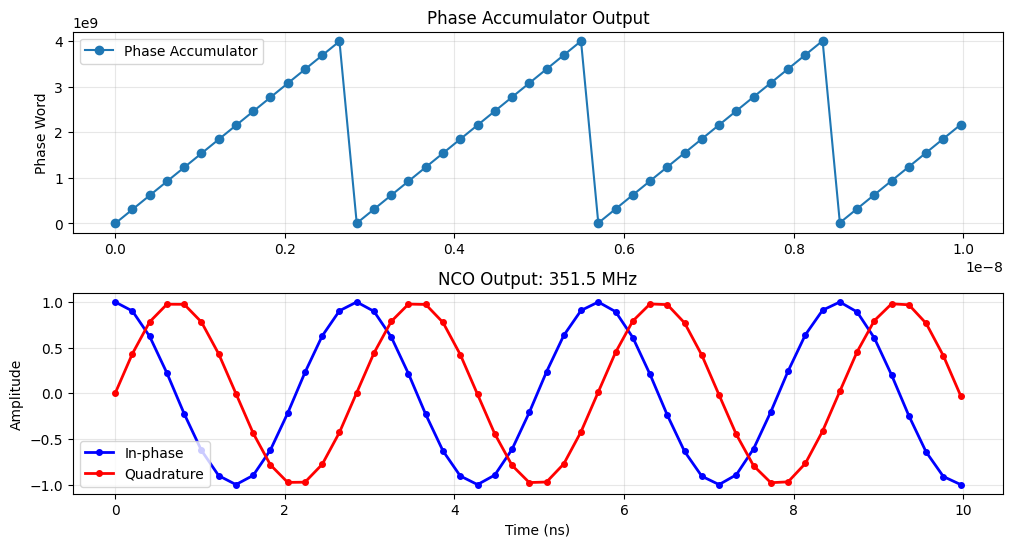

In [7]:
# Generate 200 MHz carrier
freq_carrier = 1406.e6/4 # frequency inHz
duration = 10e-9         # 10 ns
num_samples = duration * FREQ_DAC
time_nco, I_nco, Q_nco = run_nco(freq_carrier, phase_offset_deg=0, num_samples=num_samples, plot=True)

## 3. Direct Digital Synthesizer (DDS)

The DDS generates the envelope and modulation waveforms and mixes it digitally with the NCO carrier.

### 3.1 Waveform Generation

In [12]:
def waveform(pulse_len, amplitude=32000, duration=None, sample_offset=0, 
             type='CONST', I_waveform=True, Q_waveform=False):
    """Generate a digital waveform. 
    Notes:
        Currently only constant pulse types are supported
    
    Args:
        pulse_len: Duration of pulse (samples)
        amplitude: Peak amplitude (DAC units) [-2^15, 2^15)
        duration: Duration of waveform (samples)
        sample_offset: Initial pulse offset (samples)
        type: pulse type (only const supported)
        I_waveform: Whether to generate rect pulse in In-phase
        I_waveform: Whether to generate rect pulse in Quadrature
    Returns:
        tuple: (time_array, I_signal_array, Q_signal_array)
    """
    total_samples = (sample_offset + pulse_len + SAMPLES_PER_TPROC-1)\
                        // SAMPLES_PER_TPROC * SAMPLES_PER_TPROC

    if duration:
        if duration % SAMPLES_PER_TPROC != 0:
            raise KeyError(f"Duration must be a multiple of {SAMPLES_PER_TPROC}, in order to sync with tproc")
        if duration >= total_samples:
            total_samples = duration
        else:
            raise KeyError(f"Duration must be longer than pulse_len {pulse_len} + sample_offset {sample_offset}")
        
    if (amplitude < -2**15 or amplitude > 2**15):
        raise KeyError(f"Amplitude must be in [-2^15, 2^15)")

    t = np.arange(duration) / FREQ_WVFM
    
    signal = np.zeros(total_samples)
    
    if (type=='CONST'):
        signal[sample_offset: sample_offset+pulse_len] = amplitude*np.ones(pulse_len)

    I_signal = signal if I_waveform else np.zeros(total_samples)
    Q_signal = signal if Q_waveform else np.zeros(total_samples)

    print(f"Samples: {total_samples}")
    print(f"Percent of Waveform Memory: {total_samples/WAVEFORM_MEMORY*100:0.2f}%")

    return t, I_signal.astype(int), Q_signal.astype(int)

def plot_waveform(time, I_signal=None, Q_signal=None, title="DDS Waveform",
                  legend=True, ax=None, show=True):
    
    dt = np.mean(np.diff(time))
    offset = 0.1 * dt if (I_signal is not None and Q_signal is not None) else 0

    if I_signal is None and Q_signal is None:
        raise KeyError("Must enter either I or Q waveforms (or both)")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))

    legend_elements = []

    if I_signal is not None:
        markerline_I, stemlines_I, _ = ax.stem((time - offset) * 1e9, I_signal, basefmt=" ")
        plt.setp(stemlines_I, color='blue', linewidth=1.5, alpha=0.6)
        plt.setp(markerline_I, color='blue', markersize=5, alpha=0.6)
        legend_elements.append(Line2D([0], [0], color='blue', lw=1.5,
                                      label='In-phase', alpha=0.6))

    if Q_signal is not None:
        markerline_Q, stemlines_Q, _ = ax.stem((time + offset) * 1e9, Q_signal, basefmt=" ")
        plt.setp(stemlines_Q, color='red', linewidth=1.5, alpha=0.6)
        plt.setp(markerline_Q, color='red', markersize=5, alpha=0.6)
        legend_elements.append(Line2D([0], [0], color='red', lw=1.5,
                                      label='Quadrature', alpha=0.6))

    ax.set_ylabel("DDS Amplitude\n(DAC units)")
    ax.set_title(title)

    total_samples = max(len(I_signal) if I_signal is not None else 0,
                        len(Q_signal) if Q_signal is not None else 0)

    if total_samples < 100 * 16:
        for t in time:
            ax.axvline(t * 1e9, color='gray', alpha=0.2, linewidth=0.8)

    if total_samples < 300 * 16:
        for t in time[::SAMPLES_PER_TPROC]:
            ax.axvline(t * 1e9, color='k', alpha=0.5,
                       linewidth=1.2, linestyle='--')

    ax.axhline(2**15, color='red', alpha=0.3)
    ax.axhline(-2**15, color='red', alpha=0.3)
    ax.set_ylim((-2**15 - 1e3, 2**15 + 1e3))

    if legend:
        ax.legend(handles=legend_elements, loc='upper right')

    if show:
        plt.tight_layout()
        plt.show()

### 3.2 DDS Demonstration

Generate a modulation waveform with 23 cycles.

Samples: 48
Percent of Waveform Memory: 0.07%


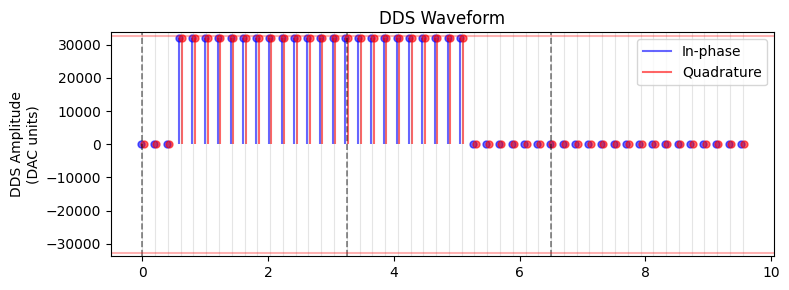

In [9]:
# Generate DDS waveform
time_dds, I_signal_dds, Q_signal_dds = waveform(23, amplitude=32000, duration=48, sample_offset=3, Q_waveform=True)
plot_waveform(time_dds, I_signal=I_signal_dds, Q_signal=Q_signal_dds)

## 4. Signal Mixing and Upsampling

The I & Q channels of the DDS (Waveform/Envelope) and NCO signals get mixed together.

The resulting I & Q signals then get added together

### 4.1 Upsampling

In [10]:
def mix_signals(time_nco, signal_nco, time_dds, signal_dds, upsample_factor=1):
    """Mix NCO carrier with DDS waveform, with optional upsampling for visualization.
    
    This function performs the mixing operation that occurs in the DAC:
    - NCO provides the carrier (runs at full DAC rate, 4915.2 MHz)
    - DDS provides the modulation envelope (16 samples per tproc cycle)
    - Output is the product of these two signals
    
    Args:
        time_nco: Time array for NCO signal
        signal_nco: NCO carrier signal (cosine or sine wave)
        time_dds: Time array for DDS signal  
        signal_dds: DDS waveform signal
        upsample_factor: Interpolation factor for smoother visualization (default=1)
                        - 1 = no upsampling (shows discrete samples)
                        - 10-50 = smoother plots (better represents continuous analog output)
    
    Returns:
        tuple: (time_mixed, signal_mixed)
        
    Note:
        - NCO is interpolated linearly (continuous carrier wave)
        - DDS uses zero-order hold (sample-and-hold from tproc)
    """
    
    if upsample_factor > 1:
        # Create upsampled time array
        time_mixed = np.linspace(time_nco[0], time_nco[-1], 
                                 len(time_nco) * upsample_factor)
        
        # Upsample NCO with linear interpolation (represents continuous analog carrier)
        nco_upsampled = np.interp(time_mixed, time_nco, signal_nco)
        
        # Upsample DDS with zero-order hold (represents tproc sample-and-hold)
        # Each DDS sample is held constant until the next tproc update
        dds_indices = np.searchsorted(time_dds, time_mixed, side='right') - 1
        dds_indices = np.clip(dds_indices, 0, len(signal_dds) - 1)
        dds_upsampled = signal_dds[dds_indices]
        
    else:
        # No upsampling - work at native NCO sample rate
        time_mixed = time_nco
        nco_upsampled = signal_nco
        
        # Match DDS to NCO timebase using zero-order hold
        dds_indices = np.searchsorted(time_dds, time_mixed, side='right') - 1
        dds_indices = np.clip(dds_indices, 0, len(signal_dds) - 1)
        dds_upsampled = signal_dds[dds_indices]
    
    # Perform mixing (multiplication in the DAC)
    signal_mixed = nco_upsampled * dds_upsampled
    
    return time_mixed, signal_mixed


def plot_mixed_signal(time, I_mixed_signal, Q_mixed_signal=None,
                      title="Mixed RF Output",
                      show_samples=True, show_sum=False,
                      only_sum=False, ax=None, show=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    plot_sum = show_sum or only_sum

    if I_mixed_signal is not None and not only_sum:
        ax.plot(time * 1e9, I_mixed_signal, 'b-',
                linewidth=1.5, alpha=0.7, label='I Mixed')

    if Q_mixed_signal is not None and not only_sum:
        ax.plot(time * 1e9, Q_mixed_signal, 'r-',
                linewidth=1.5, alpha=0.7, label='Q Mixed')

    if plot_sum:
        ax.plot(time * 1e9, I_mixed_signal + Q_mixed_signal,
                'm-', linewidth=1.5, alpha=1,
                label='Summed RF')

    ax.set_ylabel("RF Amplitude")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if show:
        ax.set_xlabel("Time (ns)")
        plt.tight_layout()
        plt.show()


In [11]:
def plot_dds_and_mixed(
    time_dds, I_dds, Q_dds,
    time_mixed, I_mixed, Q_mixed=None,
    title="DDS → RF Mixing Visualization",
    show_sum=False,
    only_sum=False
):
    """
    Joint DDS + Mixed RF plot with shared time axis.

    Args:
        show_sum: Overlay summed (I+Q) mixed signal
        only_sum: Plot ONLY the summed signal (no I/Q)
    """

    fig, (ax_dds, ax_mix) = plt.subplots(
        2, 1,
        figsize=(12, 6),
        sharex=True,
        gridspec_kw={'height_ratios': [1, 1.2]}
    )

    # ── DDS subplot ─────────────────────────────────────
    plot_waveform(
        time_dds,
        I_signal=I_dds,
        Q_signal=Q_dds,
        title="DDS Modulation",
        ax=ax_dds,
        show=False
    )

    # ── Mixed RF subplot ────────────────────────────────
    plot_mixed_signal(
        time_mixed,
        I_mixed_signal=I_mixed,
        Q_mixed_signal=Q_mixed,
        title="Mixed RF Output",
        show_sum=show_sum,
        only_sum=only_sum,
        ax=ax_mix,
        show=False
    )

    ax_mix.set_xlabel("Time (ns)")
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()


### 4.2 Complete Signal Chain

Demonstrate the complete signal generation process from NCO through mixing to final RF output.

Step 1: Generate NCO Carrier
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz


C:\Users\vsmar\AppData\Local\Temp\ipykernel_61232\2146394358.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


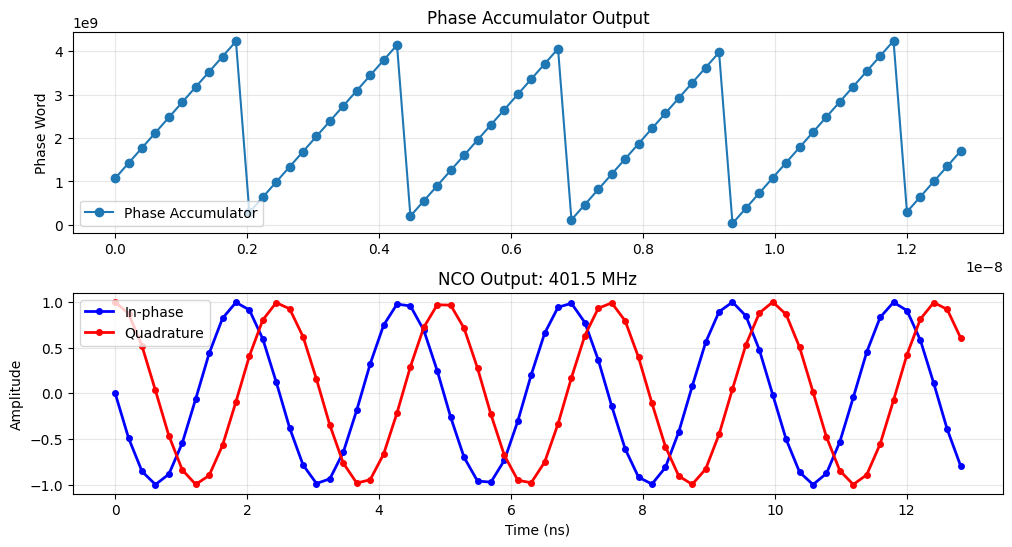


Step 2: Generate DDS Modulation
Samples: 64
Percent of Waveform Memory: 0.10%
Step 3a: Mix I Signals


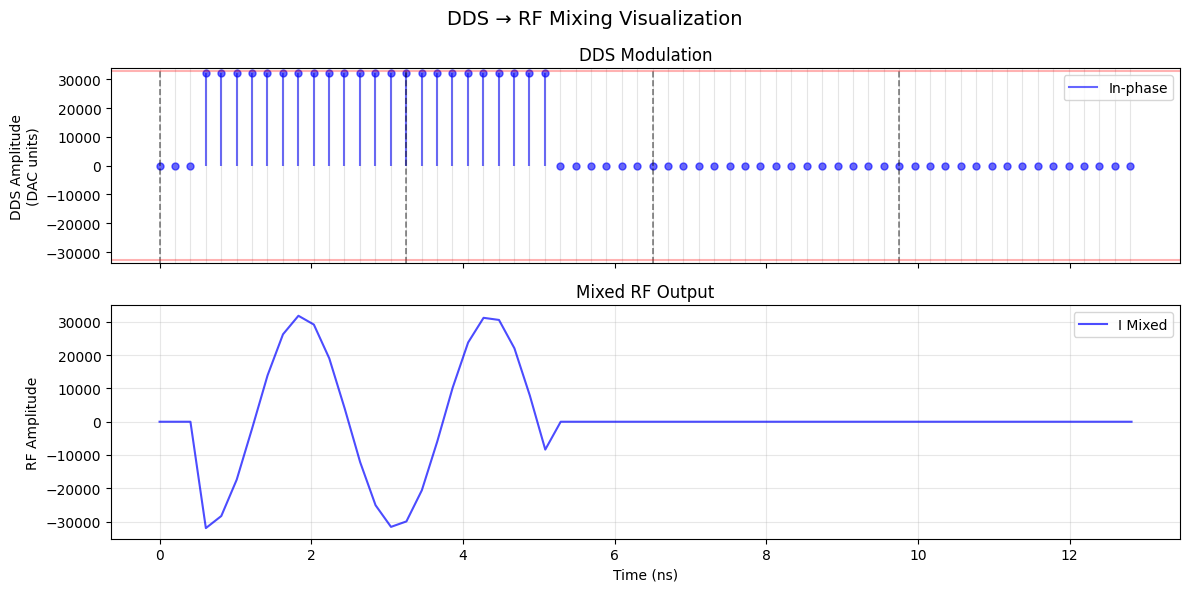

Step 3b: Mix I Signals - Upsampled (Visualize Analog Output)


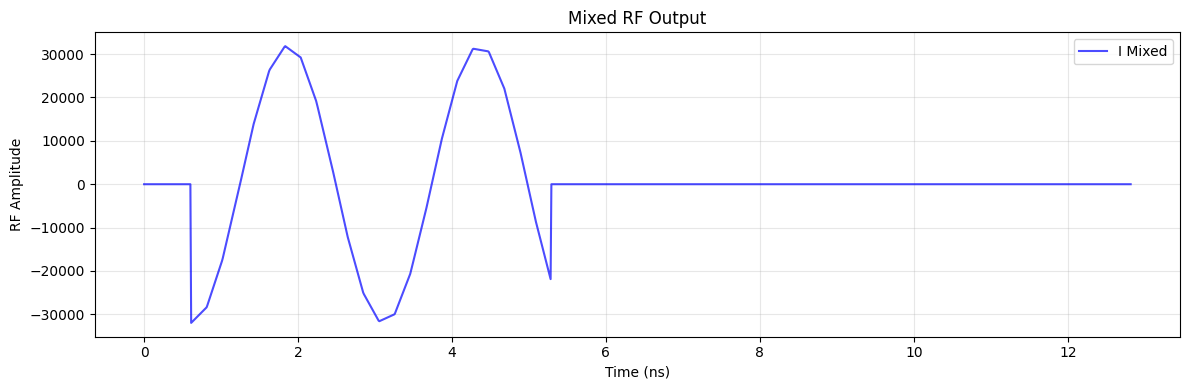

Step 3c: Mix I Signals - Continuous LO


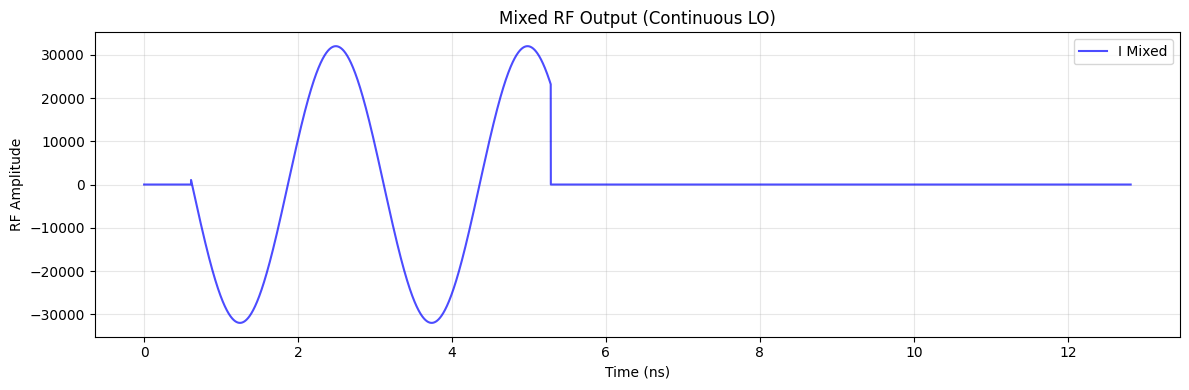

In [ ]:
# Generate NCO carrier
print("Step 1: Generate NCO Carrier")
print("=" * 40)
time_nco, I_nco, Q_nco = run_nco(freq_carrier, phase_offset_deg=90, num_samples=64, plot=True)

# Generate DDS modulation
print("\nStep 2: Generate DDS Modulation")
print("=" * 40)
time_dds, I_signal_dds, Q_signal_dds = waveform(23, amplitude=32000, duration=64, sample_offset=3)

# Mix WITHOUT upsampling
# this might be useful for FFTs
print("Step 3a: Mix I Signals")
print("=" * 40)
time_mixed_discrete, signal_mixed_discrete = mix_signals(
    time_nco, I_nco, time_dds, I_signal_dds, upsample_factor=1
)

# Plot DDS and Mixed Signals
plot_dds_and_mixed(
    time_dds, I_signal_dds, None,
    time_mixed_discrete, signal_mixed_discrete
)

# Mix WITH upsampling
print("Step 3b: Mix I Signals - Upsampled (Visualize Analog Output)")
print("=" * 40)
time_mixed_smooth, signal_mixed_smooth = mix_signals(
    time_nco, I_nco, time_dds, I_signal_dds, upsample_factor=20
)
plot_mixed_signal(time_mixed_smooth, signal_mixed_smooth, title="Mixed RF Output", show_samples=False)

# Mix WITH continuous substitution for NCO
print("Step 3c: Mix I Signals - Continuous LO")
print("=" * 40)
time_cont = np.linspace(time_nco[0], time_nco[-1], 10000)
I_nco_cont = np.cos(freq_carrier * 2*np.pi * time_cont)
time_mixed_cont, signal_mixed_cont = mix_signals(
    time_cont, I_nco_cont, time_dds, I_signal_dds, upsample_factor=20
)
plot_mixed_signal(time_mixed_cont, signal_mixed_cont, title="Mixed RF Output (Continuous LO)", show_samples=False)


Samples: 64
Percent of Waveform Memory: 0.10%


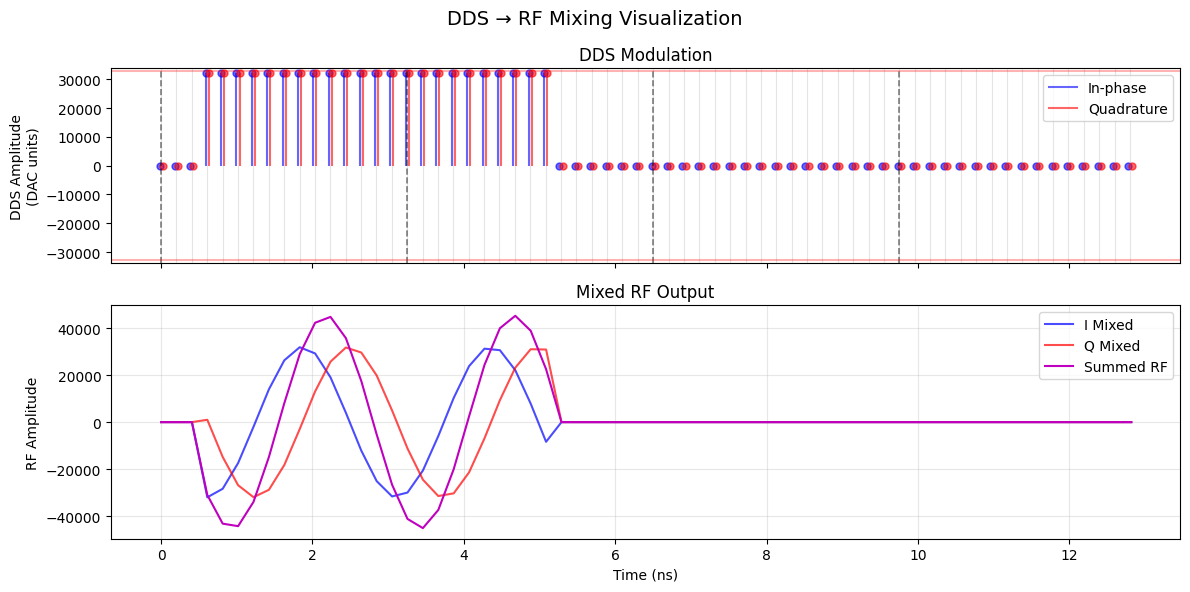

In [ ]:
time_dds, I_signal_dds, Q_signal_dds = waveform(23, amplitude=32000, duration=64, sample_offset=3, Q_waveform=True)

time_mixed_discrete, I_mixed_discrete = mix_signals(
    time_nco, I_nco, time_dds, I_signal_dds, upsample_factor=1
)
time_mixed_discrete, Q_mixed_discrete = mix_signals(
    time_nco, Q_nco, time_dds, Q_signal_dds, upsample_factor=1
)

plot_dds_and_mixed(
    time_dds, I_signal_dds, Q_signal_dds,
    time_mixed_discrete, I_mixed_discrete, Q_mixed_discrete, show_sum=True
)

## 5. Arbitrary Waveforms

Using DDS to encode waveforms with phase and frequency elements

### 5.1 Gaussian pulses

In [ ]:
# QICK defines parameter GAUSS_BUG in order to address a bug
# I'm not sure if the bug is present in the variant of QICK-DAWG in use.
GAUSS_BUG = False

def waveform_gauss(length_treg, sigma_treg, amplitude=32000, I_waveform=True, Q_waveform=False):
    """Generate a I channel DDS waveform simulating 'add_gauss' in 'AbsQickProgram'.
    Generates a Gaussian pulse centered in the waveform.
    
    Args:
        length: Duration of pulse (fabric/tproc clocks, 16 × samples)
        sigma: Standard deviation of the Gaussian (fabric/tproc clocks, 16 × samples)
        amplitude: Peak amplitude (DAC units) [-2^15, 2^15)
    Returns:
        tuple: (time_array, signal_array)
    """
    if GAUSS_BUG:
        sigma /= np.sqrt(2.0)


    if (amplitude < -2**15 or amplitude > 2**15):
        raise KeyError(f"Amplitude must be in [-2^15, 2^15)")

    length_samples = int(length_treg) * SAMPLES_PER_TPROC
    sigma_samples = int(sigma_treg) * SAMPLES_PER_TPROC

    x = np.arange(0, length_samples)

    mu = length_samples/2-0.5

    y = amplitude * np.exp(-(x-mu)**2/(2*sigma_samples**2))

    t = x / FREQ_DDS

    I_signal = y if I_waveform else np.zeros_like(y)
    Q_signal = y if Q_waveform else np.zeros_like(y)

    print(f"Samples: {length_samples}")
    print(f"Percent of Waveform Memory: {length_samples/WAVEFORM_MEMORY*100:0.2f}%")

    return t, I_signal.astype(int), Q_signal.astype(int)

Samples: 80
Percent of Waveform Memory: 0.12%
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz


C:\Users\vsmar\AppData\Local\Temp\ipykernel_61232\2146394358.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


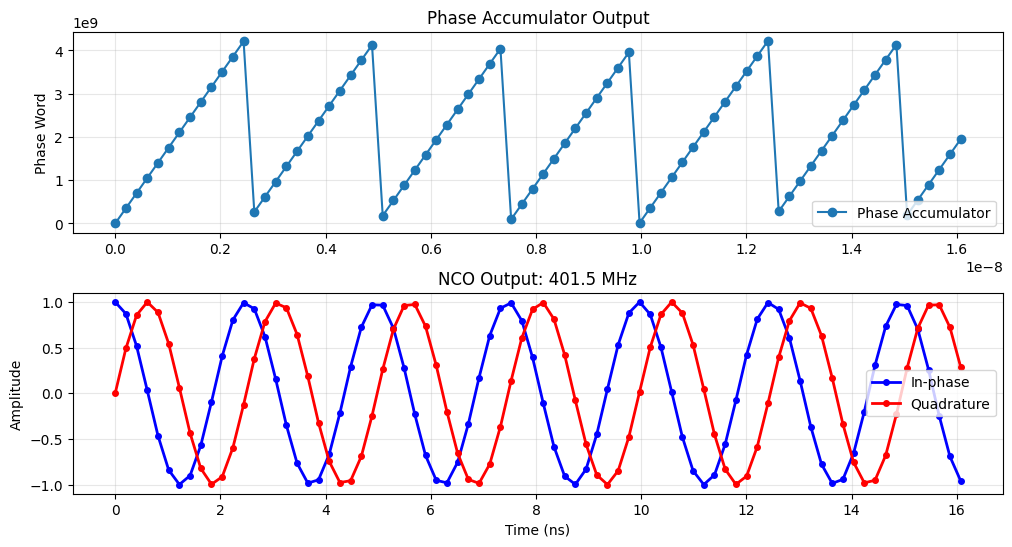

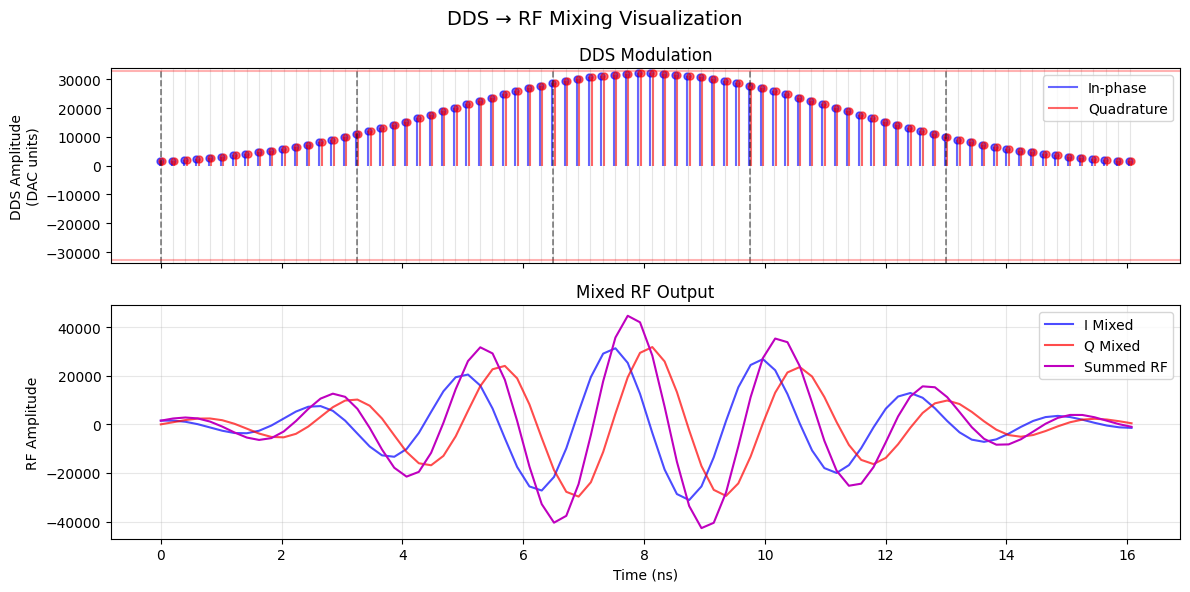

In [ ]:
time_dds_gauss, I_signal_dds_gauss, Q_signal_dds_gauss,  = waveform_gauss(length_treg=5, sigma_treg=1, amplitude=32000, Q_waveform=True)

time_nco, I_nco, Q_nco = run_nco(freq_carrier, phase_offset_deg=0, num_samples=5*16, plot=True)
time_mixed_discrete, I_mixed_discrete = mix_signals(
    time_nco, I_nco, time_dds_gauss, I_signal_dds_gauss, upsample_factor=1
)

time_mixed_discrete, Q_mixed_discrete = mix_signals(
    time_nco, Q_nco, time_dds_gauss, Q_signal_dds_gauss, upsample_factor=1
)


plot_dds_and_mixed(
    time_dds_gauss, I_signal_dds_gauss, Q_signal_dds_gauss,
    time_mixed_discrete, I_mixed_discrete, Q_mixed_discrete, show_sum=True
)

### 5.2 Chirped pulses

In [ ]:
# Make a chirped pulse
def chirped(freq_start, freq_end, length_treg, amplitude=3200):
    """Generate I & Q DDS waveforms to modulate the NCO's frequency into a chirped pulse.
    
    Args:
        freq_start: 
        freq_end: 
        length: Duration of pulse (fabric/tproc clocks, 16 × samples)
        amplitude: Peak amplitude (DAC units) [-2^15, 2^15)
    Returns:
        tuple: (time_array, signal_array)
    """
    length_samp = length_treg * SAMPLES_PER_TPROC
    x = np.arange(length_samp)
    t = x / FREQ_DDS

    k = (freq_end - freq_start) / (length_samp / FREQ_DDS)
    phase = 2*np.pi * (freq_start * t + 1/2 * k * t**2)
    i_waveform = np.cos(phase) * amplitude
    q_waveform = np.sin(phase) * amplitude

    return t, i_waveform.astype(int), q_waveform.astype(int)

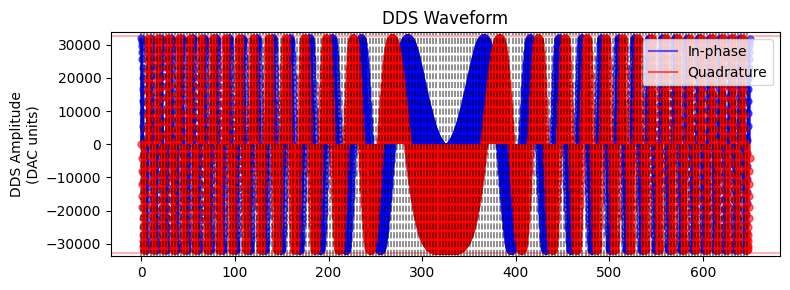

In [ ]:
time_dds_chirp, I_dds_chirp, Q_dds_chirp = chirped(freq_start=-100e6, freq_end=100e6, length_treg=200, amplitude=32000)

plot_waveform(time_dds_chirp, I_dds_chirp, Q_dds_chirp)

Desired Frequency: 251.500000 MHz
FCW: 219764053 (0x0D195555, or 0.026 rad)
Actual Frequency: 251.499999619 MHz
Frequency Error: -0.631 Hz


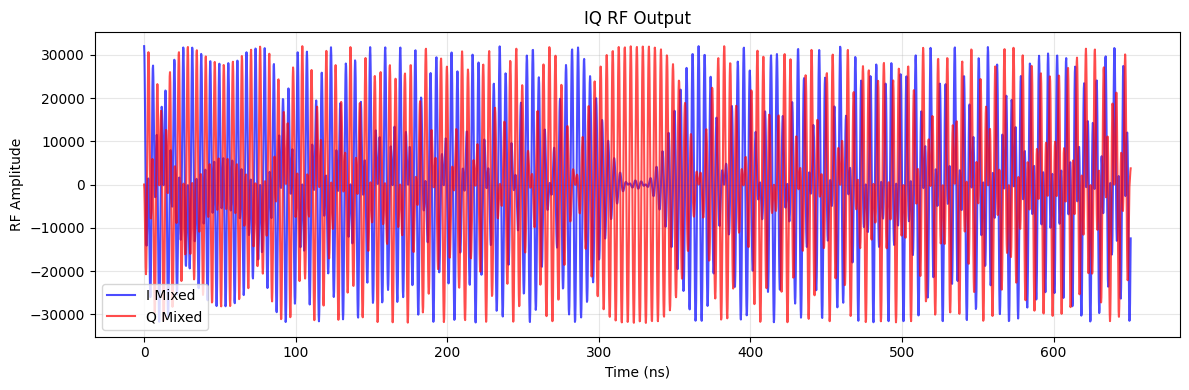

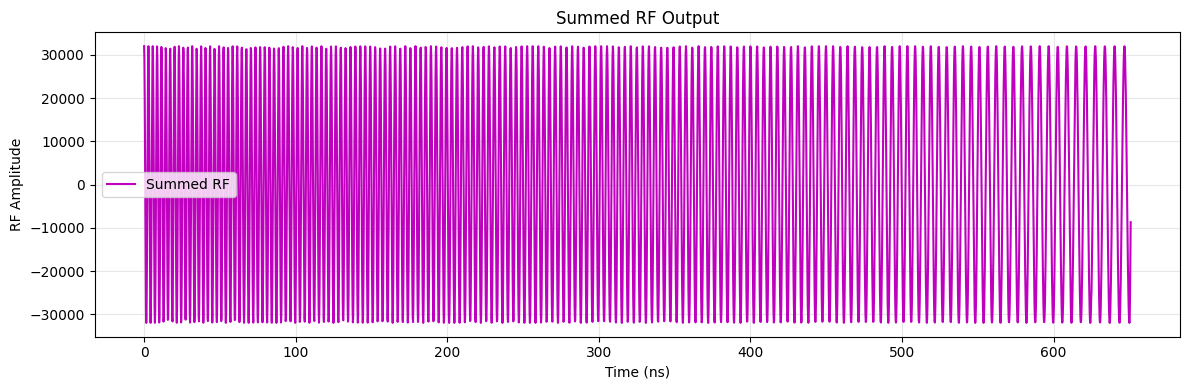

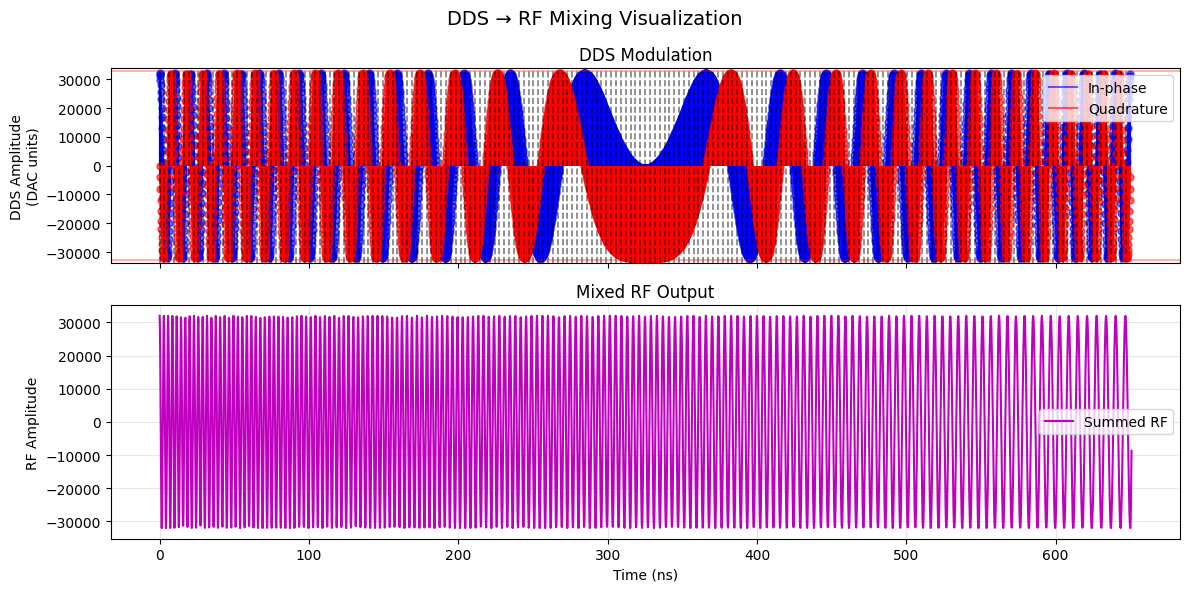

In [ ]:
time_nco, I_nco, Q_nco = run_nco(freq_carrier-150e6, phase_offset_deg=0, num_samples=len(time_dds_chirp), plot=False)

time_mixed_discrete, I_mixed_discrete = mix_signals(
    time_nco, I_nco, time_dds_chirp, I_dds_chirp, upsample_factor=1
)

time_mixed_discrete, Q_mixed_discrete = mix_signals(
    time_nco, Q_nco, time_dds_chirp, Q_dds_chirp, upsample_factor=1
)

# Plot I & Q RF Output
plot_mixed_signal(time_mixed_discrete, I_mixed_discrete, Q_mixed_discrete, title="IQ RF Output", show_samples=True)

# Plot sum only
plot_mixed_signal(time_mixed_discrete, I_mixed_discrete, Q_mixed_discrete, title="Summed RF Output", show_samples=True, only_sum=True)


plot_dds_and_mixed(
    time_dds_chirp, I_dds_chirp, Q_dds_chirp,
    time_mixed_discrete, I_mixed_discrete, Q_mixed_discrete, only_sum=True
)

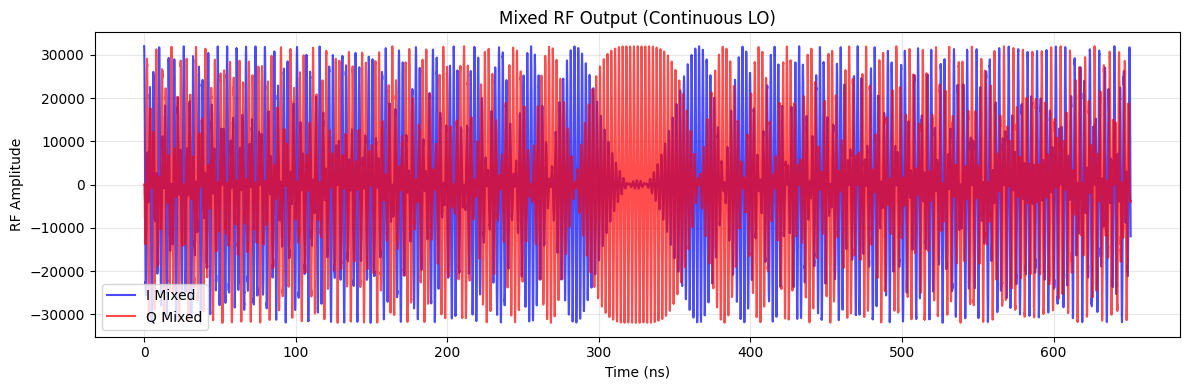

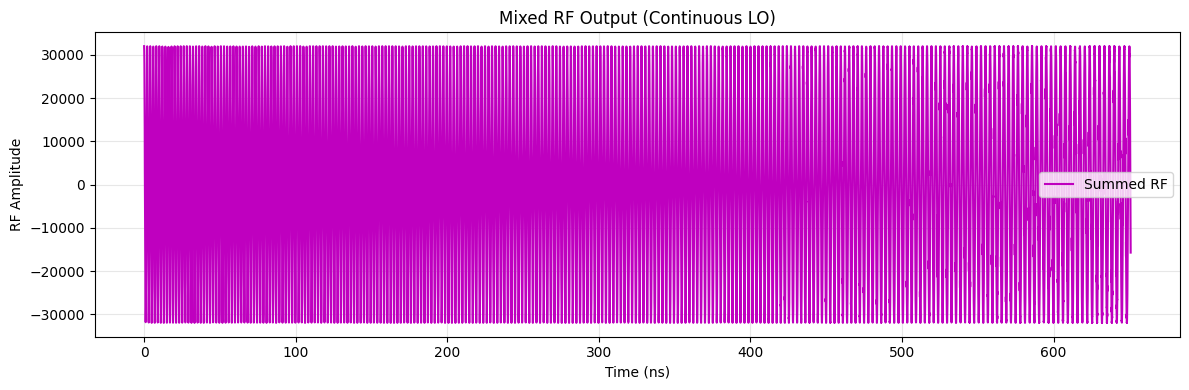

In [ ]:
time_cont = np.linspace(time_nco[0], time_nco[-1], 10000)
I_nco_cont = np.cos(freq_carrier * 2*np.pi * time_cont)
Q_nco_cont = np.sin(freq_carrier * 2*np.pi * time_cont)

time_mixed_cont, I_mixed_cont = mix_signals(
    time_cont, I_nco_cont, time_dds_chirp, I_dds_chirp, upsample_factor=20
)

time_mixed_cont, Q_mixed_cont = mix_signals(
    time_cont, Q_nco_cont, time_dds_chirp, Q_dds_chirp, upsample_factor=20
)

plot_mixed_signal(time_mixed_cont, I_mixed_cont, Q_mixed_cont, title="Mixed RF Output (Continuous LO)", show_samples=False)

plot_mixed_signal(time_mixed_cont, I_mixed_cont, Q_mixed_cont, title="Mixed RF Output (Continuous LO)", show_samples=False, only_sum=True)

## 6. Sequencing Waveforms

Combining Waveforms. Waveforms must not overlap temporaly, but can be immediately sequenced after each other, provided the FPGA (tproc), does not buffer underflow.

Note: QICK/QICK-DAWG does not warn or notify a user of buffer underflow, this can cause unexpected delays. Buffer Underflow however is generally deterministic on the RFSoC, therefore the best way to avoid unexpected delays is to check sequences on an oscilliscope.

### 6.1

Additional Ideas:

- implement unit conversion, and working with treg or tsamps / tdss
- Unify the different waveform functions for better interoperability
- Add sequences (no overlap)
- Add Chirp waveform
- Improve waveform memroy indication

- GUI

GUI Idea:
- selection between the 3 waveform types (initially just rectangular waveforms)
- Sliders to change the amplitude of the waveforms (user modifies amplitude of I and Q dds)
- Slider to change the phase of the resulting waveform (program modifies amplitude of I and Q dds)
- Range from -2^15 to 2^15 for dds amplitude


## References

QICK
- [QICK Documentation](https://qick-docs.readthedocs.io/)
- [QICK Github](https://github.com/openquantumhardware/qick)

QICK-DAWG
- [QICK-DAWG Documentation](https://qick-dawg.readthedocs.io/en/stable/index.html)
- [QICK-DAWG Github](https://github.com/sandialabs/qick-dawg)

RFSoC
- [RFSoC 4x2 User Guide](http://www.rfsoc-pynq.io/)
- [RFSoC Book](https://www.rfsocbook.com/)
- [RFSoC Reference Manual (pdf)](https://www.realdigital.org/downloads/15456c97a4fe5a1ee66208c5aa3894bb.pdf)

NCOs
- [NCO & DDS Overview](https://john-gentile.com/kb/dsp/NCO_DDS.html)


Step 1: Generate NCO Carrier
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz


C:\Users\vsmar\AppData\Local\Temp\ipykernel_61232\2146394358.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


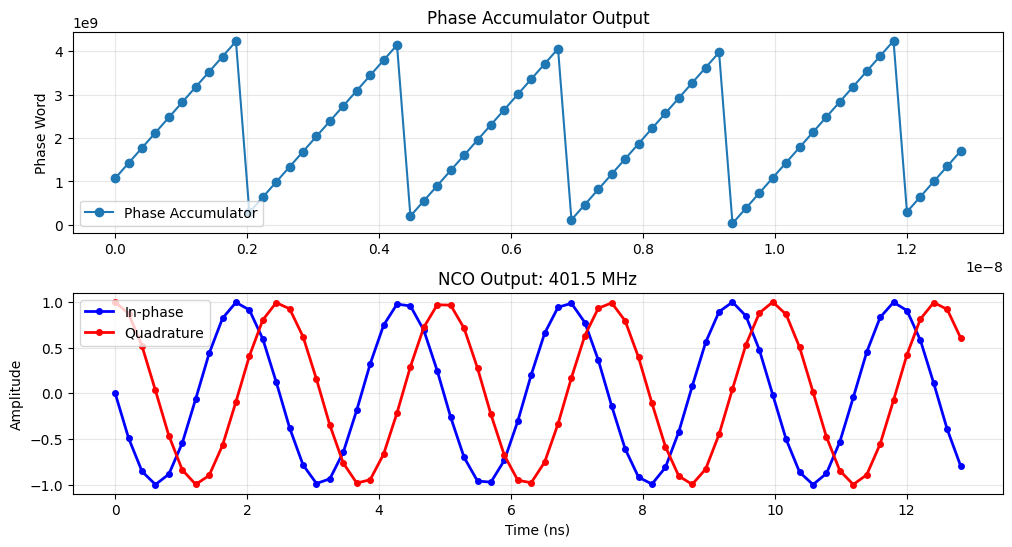


Step 2: Generate DDS Modulation
Samples: 64
Percent of Waveform Memory: 0.10%


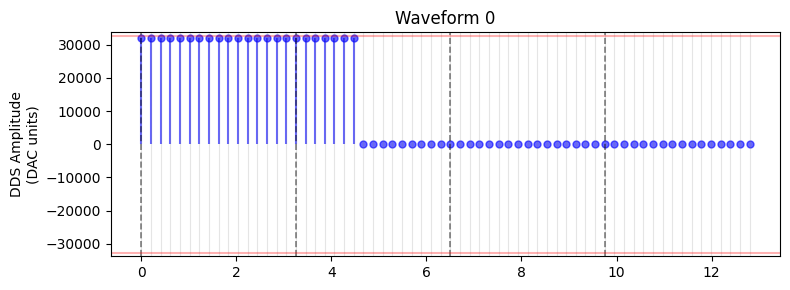

Step 3a: Mix I Signals


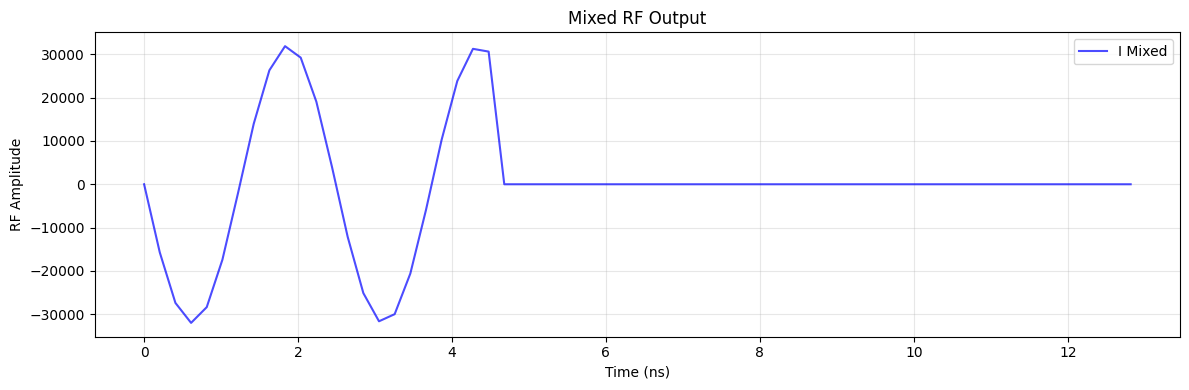

Step 3b: Mix I Signals - Upsampled (Visualize Analog Output)


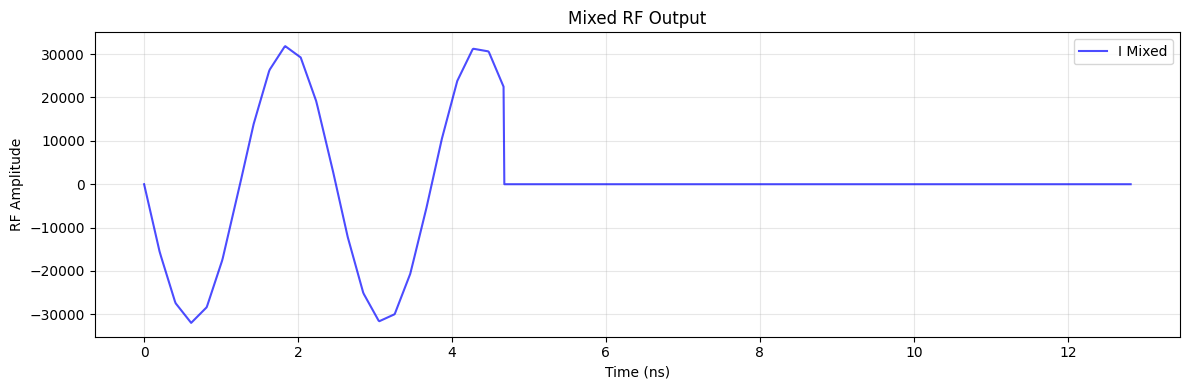

Step 3c: Mix I Signals - Continuous LO


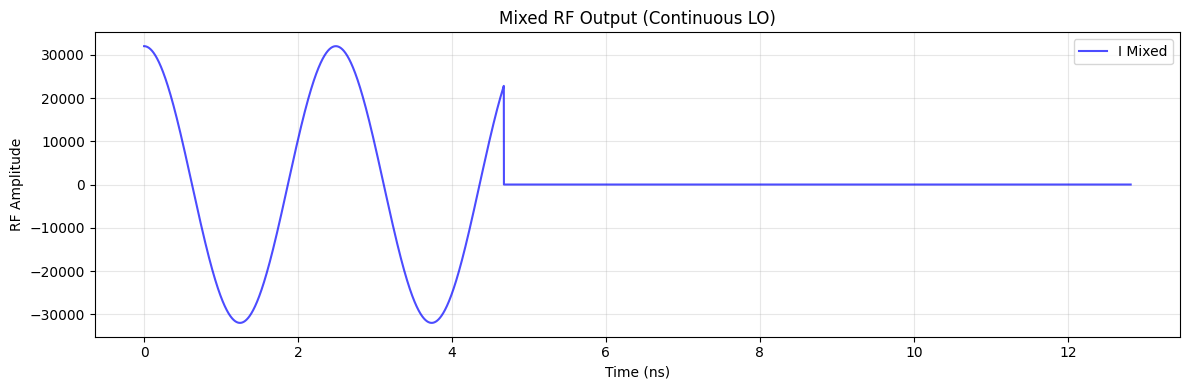

In [ ]:
# Generate NCO carrier
print("Step 1: Generate NCO Carrier")
print("=" * 40)
time_nco, I_nco, Q_nco = run_nco(freq_carrier, phase_offset_deg=90, num_samples=64, plot=True)

# Generate DDS modulation
print("\nStep 2: Generate DDS Modulation")
print("=" * 40)
time_dds, I_signal_dds, Q_signal_dds = waveform(23, amplitude=32000, duration=64, sample_offset=0, Q_waveform=True)
plot_waveform(time_dds, I_signal=I_signal_dds, title="Waveform 0", legend=False)

# Mix WITHOUT upsampling
# this might be useful for FFTs
print("Step 3a: Mix I Signals")
print("=" * 40)
time_mixed_discrete, signal_mixed_discrete = mix_signals(
    time_nco, I_nco, time_dds, I_signal_dds, upsample_factor=1
)
plot_mixed_signal(time_mixed_discrete, signal_mixed_discrete, title="Mixed RF Output", show_samples=True)

# Mix WITH upsampling
print("Step 3b: Mix I Signals - Upsampled (Visualize Analog Output)")
print("=" * 40)
time_mixed_smooth, signal_mixed_smooth = mix_signals(
    time_nco, I_nco, time_dds, I_signal_dds, upsample_factor=20
)
plot_mixed_signal(time_mixed_smooth, signal_mixed_smooth, title="Mixed RF Output", show_samples=False)

# Mix WITH continuous substitution for NCO
print("Step 3c: Mix I Signals - Continuous LO")
print("=" * 40)
time_cont = np.linspace(time_nco[0], time_nco[-1], 10000)
I_nco_cont = np.cos(freq_carrier * 2*np.pi * time_cont)
time_mixed_cont, signal_mixed_cont = mix_signals(
    time_cont, I_nco_cont, time_dds, I_signal_dds, upsample_factor=20
)
plot_mixed_signal(time_mixed_cont, signal_mixed_cont, title="Mixed RF Output (Continuous LO)", show_samples=False)


In [ ]:
def plot_waveform_in_memory(I_signals=None, Q_signals=None,
                            title="DDS Waveform", legend=True):
    """
    Plot DDS waveforms using memory addressing only.
    X-axis corresponds to memory indices scaled by SAMPLES_PER_TPROC.
    Adds vertical lines separating each waveform block.
    """

    if I_signals is None and Q_signals is None:
        raise KeyError("Must provide I or Q waveform data.")

    # Build continuous signals
    I_signal = np.concatenate(I_signals) if I_signals is not None else None
    Q_signal = np.concatenate(Q_signals) if Q_signals is not None else None

    # Determine number of samples
    total_samples = max(
        len(I_signal) if I_signal is not None else 0,
        len(Q_signal) if Q_signal is not None else 0
    )

    # Memory index (scaled by SAMPLES_PER_TPROC)
    memory_index = np.arange(total_samples) / SAMPLES_PER_TPROC

    # Compute waveform separation boundaries
    if I_signals is not None:
        lengths = [len(arr) for arr in I_signals]
    else:
        lengths = [len(arr) for arr in Q_signals]

    cumulative_boundaries = np.cumsum(lengths) / SAMPLES_PER_TPROC

    # Set up figure
    fig, ax = plt.subplots(figsize=(10, 3))
    legend_elements = []

    # Plot I samples
    if I_signal is not None:
        plt.plot(memory_index, I_signal, drawstyle='steps-post', color='blue', alpha=0.6, label='In-phase')
        plt.fill_between(memory_index, I_signal, step="post", color='blue', alpha=0.6, label='In-phase')

    # Plot Q samples
    if Q_signal is not None:
        plt.plot(memory_index, Q_signal, drawstyle='steps-post', color='red', alpha=0.6, label='Quadrature')
        plt.fill_between(memory_index, Q_signal, step="post", color='red', alpha=0.6, label='Quadrature')


    # Axis labels
    ax.set_xlabel("Waveform Memory Address (16 samples / Block)")
    ax.set_ylabel("Amplitude (DAC units)")
    ax.set_title(title)

    # Faint vertical lines for each sample
    if (total_samples < 100 * 16):
        for x in memory_index:
            ax.axvline(x, color='gray', alpha=0.3, linewidth=0.8)

    # Bold lines every SAMPLES_PER_TPROC samples
    if (total_samples < 300 * 16):
        for x in memory_index[::SAMPLES_PER_TPROC]:
            ax.axvline(x, color='k', alpha=0.5, linewidth=1.2, linestyle='--')

    # Waveform separation lines (NEW)
    all_boundaries = np.concatenate(([0], cumulative_boundaries))

    for boundary in all_boundaries:
        ax.axvline(boundary, color='green', alpha=0.8, linewidth=2, linestyle='-')


    # DAC clipping lines
    ax.axhline(2**15, color='red', alpha=0.3)
    ax.axhline(-2**15, color='red', alpha=0.3)
    ax.set_ylim((-2**15 - 1000, 2**15 + 1000))
    ax.set_xticks(np.arange(int(memory_index[-1])+2)[::3])  # show every 2nd (1,3,5,…)
    ax.set_yticks([-2**15, 0, 2**15-1])


    # Legend
    if legend:
        ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()


In [2]:
I_signals = []
Q_signals = []

for i in range(4):
    time_ddsi, I_signal_ddsi, Q_signal_ddsi = waveform(23, amplitude=2**15-1, duration=48, sample_offset=i*4, Q_waveform=True)
    I_signals.append(I_signal_ddsi)
    Q_signals.append(Q_signal_ddsi)


plot_waveform_in_memory(I_signals=I_signals, Q_signals=None,
                            title="Waveform Memory", legend=False)

plot_waveform_in_memory(I_signals=None, Q_signals=I_signals,
                            title="Waveform Memory", legend=False)

NameError: name 'waveform' is not defined

Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.631 Hz
464
Step 1: Generate NCO Carrier
Desired Frequency: 401.500000 MHz
FCW: 350836053 (0x14E95555, or 0.041 rad)
Actual Frequency: 401.499999619 MHz
Frequency Error: -0.6

C:\Users\vsmar\AppData\Local\Temp\ipykernel_61232\2146394358.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


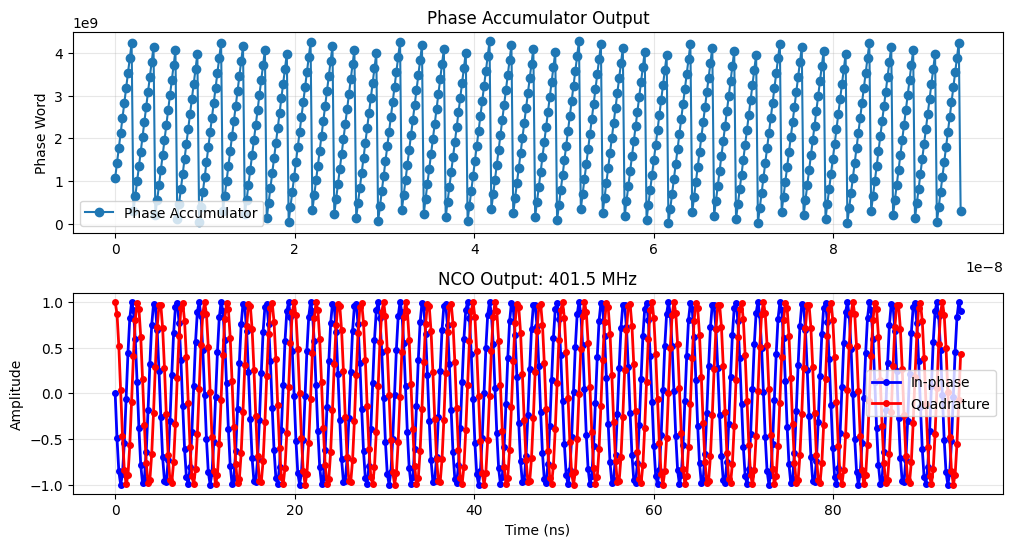

Step 3a: Mix I Signals


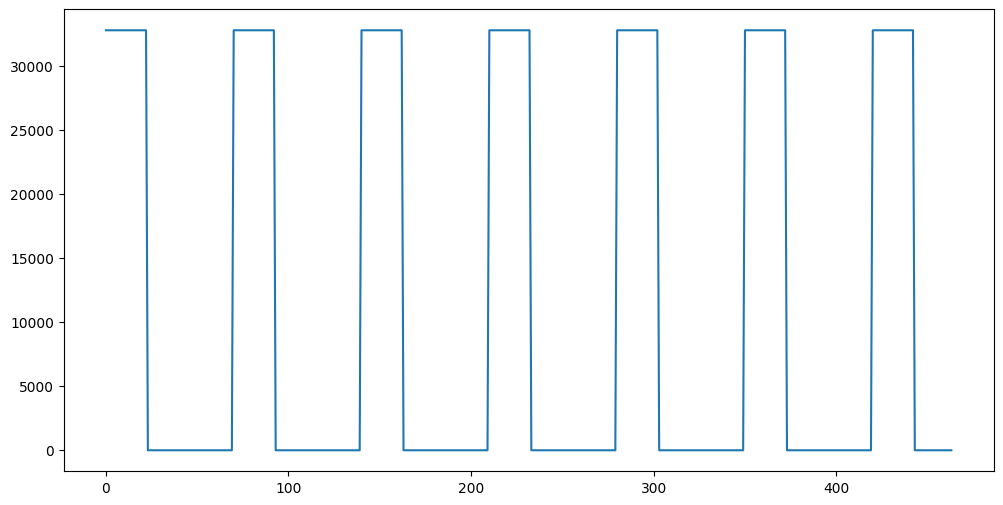

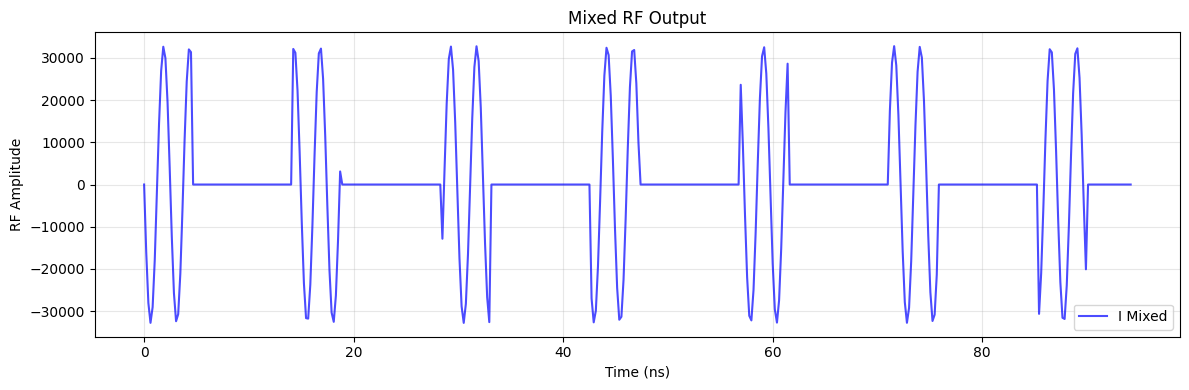

Step 3b: Mix I Signals - Upsampled (Visualize Analog Output)


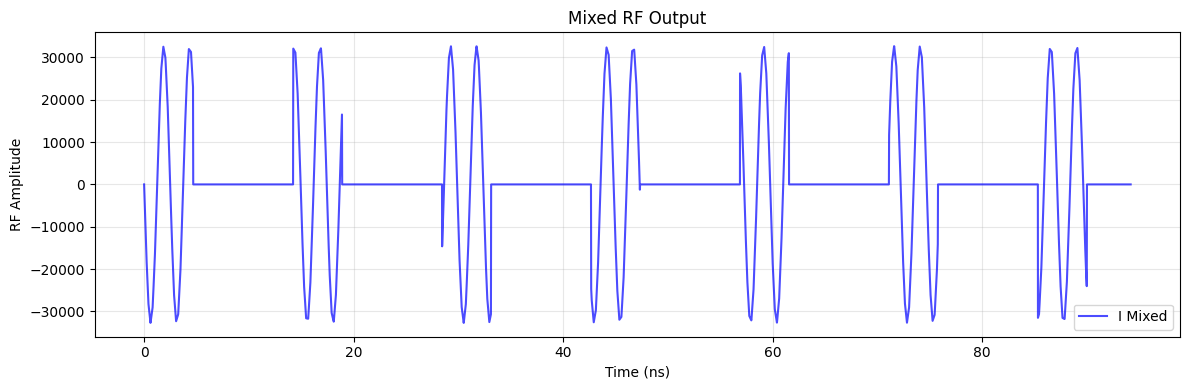

Step 3c: Mix I Signals - Continuous LO


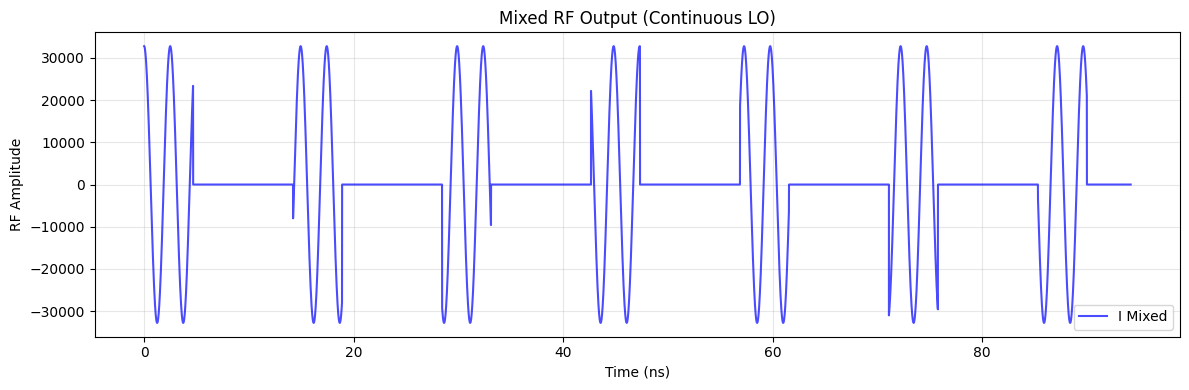

In [41]:
n_pulses = 6
Tau = 47
deadtime = 48-23

# Concate DDS signals
Tau_adj = Tau - deadtime
offset_reg = 0
I_signal_dds = [I_signals[0]]
I_nco = []
phase = [0,90,0,90,90,0,90,0]

for pulse in range(n_pulses):
    delay_samples = offset_reg + Tau_adj
    offset_reg = delay_samples % SAMPLES_PER_TPROC
    delay_coarse = delay_samples // SAMPLES_PER_TPROC
    I_signal_dds.append(np.zeros(delay_coarse * 16))
    I_signal_dds.append(I_signals[offset_reg])

    
    time_ncos, I_ncos, Q_ncos = run_nco(freq_carrier, phase_offset_deg=phase[pulse%len(phase)], num_samples=len(I_signals[offset_reg]) + delay_coarse * 16, plot=False)
    I_nco.append(I_ncos)

I_signal_dds = np.concatenate(I_signal_dds)
time_dds = np.arange(len(I_signal_dds)) * 1/FREQ_DDS
print(len(I_signal_dds))
I_nco = np.concatenate(I_nco)

# Generate NCO carrier
print("Step 1: Generate NCO Carrier")
print("=" * 40)
time_nco, I_nco, Q_nco = run_nco(freq_carrier, phase_offset_deg=90, num_samples=len(I_signal_dds), plot=True)

# Plot DDS
plt.plot(I_signal_dds)

# Mix WITHOUT upsampling
# this might be useful for FFTs
print("Step 3a: Mix I Signals")
print("=" * 40)
time_mixed_discrete, signal_mixed_discrete = mix_signals(
    time_nco, I_nco, time_dds, I_signal_dds, upsample_factor=1
)
plot_mixed_signal(time_mixed_discrete, signal_mixed_discrete, title="Mixed RF Output", show_samples=True)

# Mix WITH upsampling
print("Step 3b: Mix I Signals - Upsampled (Visualize Analog Output)")
print("=" * 40)
time_mixed_smooth, signal_mixed_smooth = mix_signals(
    time_nco, I_nco, time_dds, I_signal_dds, upsample_factor=20
)
plot_mixed_signal(time_mixed_smooth, signal_mixed_smooth, title="Mixed RF Output", show_samples=False)

# Mix WITH continuous substitution for NCO
print("Step 3c: Mix I Signals - Continuous LO")
print("=" * 40)
time_cont = np.linspace(time_nco[0], time_nco[-1], 10000)
I_nco_cont = np.cos(freq_carrier * 2*np.pi * time_cont)
time_mixed_cont, signal_mixed_cont = mix_signals(
    time_cont, I_nco_cont, time_dds, I_signal_dds, upsample_factor=20
)
plot_mixed_signal(time_mixed_cont, signal_mixed_cont, title="Mixed RF Output (Continuous LO)", show_samples=False)


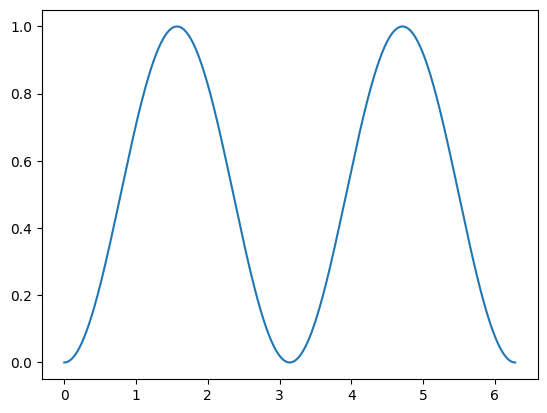

C:\Users\vsmar\AppData\Local\Temp\ipykernel_33464\1986122897.py:33: RuntimeWarning: invalid value encountered in divide
  u = (np.cos(A * np.cos(angle)) - np.cos(A))**2/(np.sin(angle)**2)


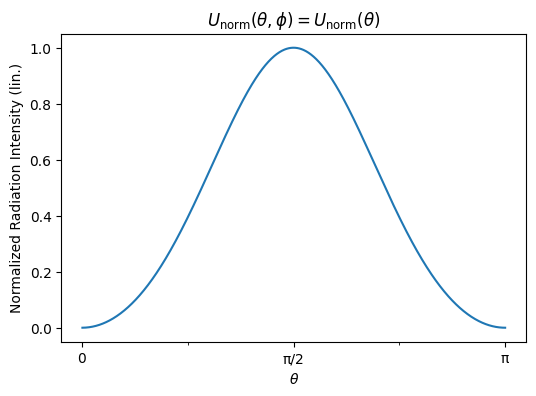

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

# k = 2*pi/lambda
# l = lambda/2

def pi_formatter(x, pos):
    # x is in radians
    m = np.pi
    # Express x as a rational multiple of pi
    frac = np.round(x / (m/2))  # multiples of π/2; change divisor for different steps
    num = int(frac)             # integer numerator over 2
    den = 2

    if num == 0:
        return "0"

    sign = "-" if num < 0 else ""
    num = abs(num)

    # Build numerator text (omit '1' when it's just π/2 or π)
    if num == den:
        return f"{sign}π"
    elif num == 1:
        return f"{sign}π/{den}"
    else:
        return f"{sign}{num}π/{den}"

angle = np.linspace(0,np.pi, 1000)

A = np.pi/2 # k*l/2
u = (np.cos(A * np.cos(angle)) - np.cos(A))**2/(np.sin(angle)**2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(angle, u)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"Normalized Radiation Intensity (lin.)")
ax.set_title(r"$U_{\text{norm}}(\theta,\phi) = U_{\text{norm}}(\theta)$")


# Put ticks every π/2
ax.xaxis.set_major_locator(MultipleLocator(base=np.pi/2))
ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

# Optional: minor ticks (e.g., π/4)
ax.xaxis.set_minor_locator(MultipleLocator(base=np.pi/4))


# fig = plt.figure()
# ax = fig.add_subplot(111, projection='polar')
# ax.plot(angle, u)

# ax.set_title("Normalized Radiation Patter")
# plt.show()

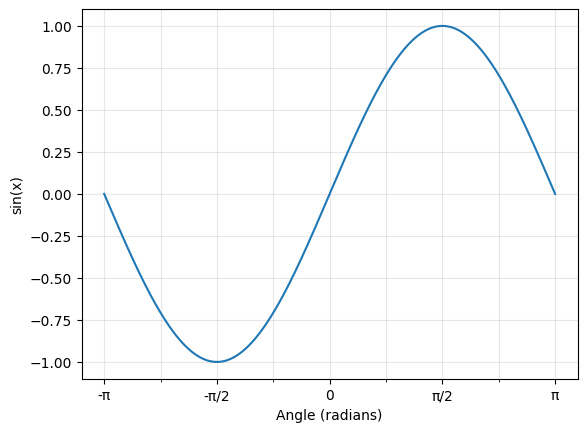

TypeError: only length-1 arrays can be converted to Python scalars

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

def pi_formatter(x, pos):
    # x is in radians
    m = np.pi
    # Express x as a rational multiple of pi
    frac = np.round(x / (m/2))  # multiples of π/2; change divisor for different steps
    num = int(frac)             # integer numerator over 2
    den = 2

    if num == 0:
        return "0"

    sign = "-" if num < 0 else ""
    num = abs(num)

    # Build numerator text (omit '1' when it's just π/2 or π)
    if num == den:
        return f"{sign}π"
    elif num == 1:
        return f"{sign}π/{den}"
    else:
        return f"{sign}{num}π/{den}"

# Example plot
x = np.linspace(-np.pi, np.pi, 400)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)

# Put ticks every π/2
ax.xaxis.set_major_locator(MultipleLocator(base=np.pi/2))
ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

# Optional: minor ticks (e.g., π/4)
ax.xaxis.set_minor_locator(MultipleLocator(base=np.pi/4))

ax.set_xlabel("Angle (radians)")
ax.set_ylabel("sin(x)")
ax.grid(True, which='both', alpha=0.3)
plt.show()


pi_formatter(u, angle)